#  EDUNET FOUNDATION - Classroom Exercise Notebook

## Step 1 : Import the Libraries and Packages
## Step 2 : Load the Dataset
## Step 3 : Exploring Data
## Step 4 : Split the data into training/testing sets
## Step 5 : Generating Model & Train the model using the training sets
## Step 6 : Visualize Decision Tree
## Step 7 : Predict the response for test dataset and Evaluate the Model

## Lab-1 Implementing Decision Tree Algorithm using Python


# Importing essential libraries

In [5]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
from sklearn import metrics

# The Iris flower data set or Fisher's Iris data set is a multivariate data set introduced by the British statistician and biologist Ronald Fisher in his 1936 paper The use of multiple measurements in taxonomic problems as an example of linear discriminant analysis.[1] It is sometimes called Anderson's Iris data set because Edgar Anderson collected the data to quantify the morphologic variation of Iris flowers of three related species.[2] Two of the three species were collected in the Gaspé Peninsula "all from the same pasture, and picked on the same day and measured at the same time by the same person with the same apparatus".

The data set consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals, in centimetres. Based on the combination of these four features, Fisher developed a linear discriminant model to distinguish the species from each other.

# Load the dataset

In [8]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [49]:

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Categorical.from_codes(iris.target, iris.target_names)
iris.target

# iris.target: This contains the class labels for the dataset as integer codes (0, 1, 2), 
# where each number corresponds to a species of iris.
# iris.target_names: This provides the actual names of the species
# (e.g., ['setosa', 'versicolor', 'virginica']).
# pd.Categorical.from_codes(...): This creates a categorical variable y using the codes and the
# corresponding category names.

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [51]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [10]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [53]:
y

['setosa', 'setosa', 'setosa', 'setosa', 'setosa', ..., 'virginica', 'virginica', 'virginica', 'virginica', 'virginica']
Length: 150
Categories (3, object): ['setosa', 'versicolor', 'virginica']

# Exploring Data

In [13]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [55]:
y = pd.get_dummies(y)

# The line y = pd.get_dummies(y) is commonly used in Python with the pandas library to convert 
# categorical variable(s) in a DataFrame (or Series) into a one-hot encoded format. 

# Input: y is typically a pandas Series or DataFrame containing categorical data.
# Function: pd.get_dummies() creates new binary columns (0 or 1) for each category in the original data. 
# Each unique category in y becomes a column, and the values are represented as
# 1 (for presence) or 0 (for absence).
y

,setosa,versicolor,virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


# Split the data into training/testing sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# Generating Model

In [18]:
dt = DecisionTreeClassifier()

# Train the model using the training sets

In [20]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

# Visualize Decision Tree

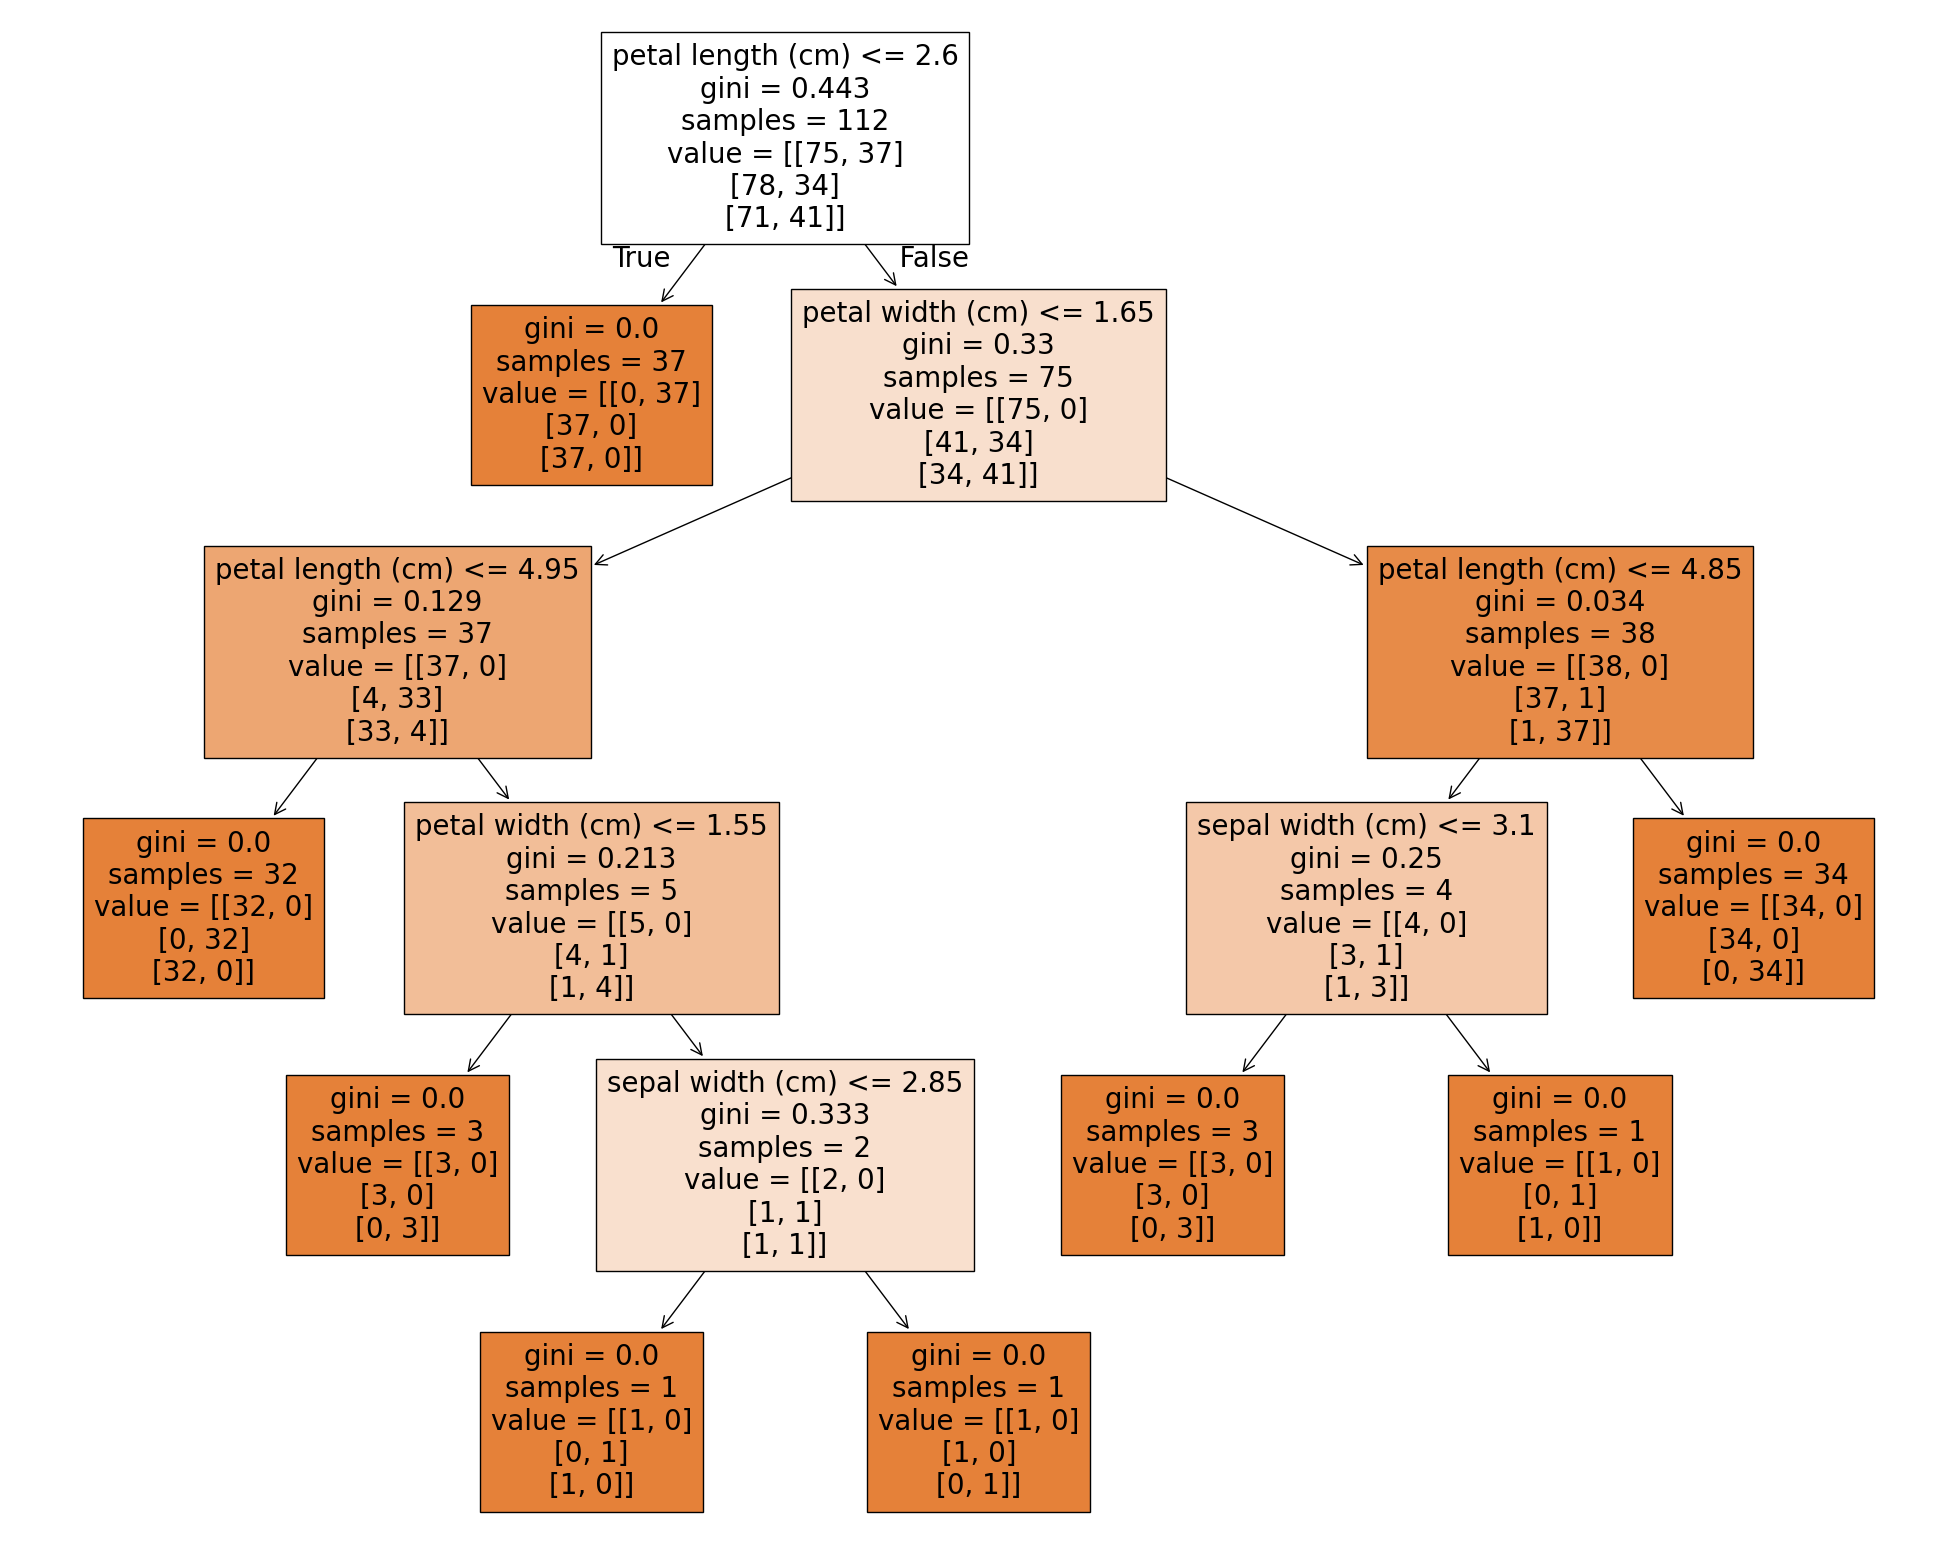

In [22]:
import matplotlib.pyplot as plt
from sklearn import tree
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(dt, 
                   feature_names=iris.feature_names,  
                   class_names=iris.target_names,
                   filled=True)



# The underscore _ is often used in Python to indicate that the returned value is being ignored. 

# feature_names = iris.feature_names: This parameter specifies the names of the features (attributes) 
# used in the decision tree. It helps label the nodes in the tree with meaningful names rather than
# just indices.

# class_names=iris.target_names: This parameter specifies the class names (the target labels). 
# It labels the leaf nodes with the names of the target classes, making it easier to understand 
# what each leaf represents.

# filled=True: This parameter colors the nodes in the tree based on the class they represent. 
# Different colors will help differentiate between classes visually, improving interpretability.

In [23]:
#_ = tree.plot_tree(dt, 
                      # filled=True)



# The underscore _ is often used in Python to indicate that the returned value is being ignored. 

# feature_names = iris.feature_names: This parameter specifies the names of the features (attributes) 
# used in the decision tree. It helps label the nodes in the tree with meaningful names rather than
# just indices.

# class_names=iris.target_names: This parameter specifies the class names (the target labels). 
# It labels the leaf nodes with the names of the target classes, making it easier to understand 
# what each leaf represents.

# filled=True: This parameter colors the nodes in the tree based on the class they represent. 
# Different colors will help differentiate between classes visually, improving interpretability.

# Predict the response for test dataset

In [25]:
y_pred = dt.predict(X_test)

# Evaluating the Model

In [27]:
# numbers on the diagonal of the confusion matrix correspond to correct predictions

species = np.array(y_test).argmax(axis=1)

# This line converts the true labels (y_test) from one-hot encoding to class indices.
# np.array(y_test) converts y_test into a NumPy array.
# .argmax(axis=1) finds the index of the maximum value along each row 
# (which corresponds to the predicted class).

predictions = np.array(y_pred).argmax(axis=1)
confusion_matrix(species, predictions)

array([[13,  0,  0],
       [ 0, 15,  1],
       [ 0,  0,  9]], dtype=int64)